# GFB Species Assignment Map
## Gary Ding &nbsp;&nbsp;&nbsp; March 2026
Assigns top native plant species to 1 km road segments by **height tier (Low / Medium / High)**,
based on coverage-weighted species distribution overlap and combined scores.

**Scoring:** `Segment Score = C × Range Weight × Coverage Fraction`

**Species selection:** top `TOP_N_PER_TIER` species per tier are read directly from the scored xlsx.
Shapefiles are auto-extracted from `SPECIES_ZIP_DIR` using the `genus[:3]+species[:4]` naming convention.

**Inputs:** pre-built `road_segments.shp`, study area boundary, species zips, scored xlsx

**Outputs:** `road_segments_scored.shp`, inline matplotlib maps

---

In [1]:
# Cell 1 - Install
!pip install -q geopandas shapely openpyxl mapclassify matplotlib
print('Ready.')

Ready.


In [18]:
# Cell 2 - Configuration

SEGMENT_LENGTH_M = 1000
BUFFER_M         = 15
TOP_N_PER_TIER   = 10          # top N species to load per height tier

RANGE_TYPE_FIELD = "GRIDCODE"
WEIGHT_ESTIMATED = 1.0         # GRIDCODE 2
WEIGHT_POSSIBLE  = 0.5         # GRIDCODE 1

MAJOR_CLASSES = ["A31", "A35"]

BOUNDARY_SHAPEFILE = "nksk.shp"
SCORES_FILE = "/Users/garyding/Desktop/gbf_top10/gonative_combined_scored_3_13.xlsx"
SCORES_SHEET       = "Combined Results"

# Folder containing the species zip files (genus3species4 naming convention)
SPECIES_ZIP_DIR = "/Users/garyding/Desktop/gbf_top10/plant-shapefiles"  # <-- update if needed

# Height tier labels
HEIGHT_TIERS  = ["L", "M", "H"]
HEIGHT_LABELS = {"L": "Low", "M": "Medium", "H": "High"}

# Per-tier accent colors used in choice maps
TIER_COLORS      = {"L": "#66BB6A", "M": "#42A5F5", "H": "#AB47BC"}
NO_SPECIES_COLOR = "#9E9E9E"

SDM_DEFAULT_CRS = "EPSG:26904"
PROJECTED_CRS   = "EPSG:32605"
OUTPUT_CRS      = "EPSG:4326"

print(f"Config: top {TOP_N_PER_TIER} species per tier, {SEGMENT_LENGTH_M} m segments, {BUFFER_M} m buffer")
print(f"Height tiers: {HEIGHT_TIERS}")


Config: top 10 species per tier, 1000 m segments, 15 m buffer
Height tiers: ['L', 'M', 'H']


In [19]:
import os
path = "/Users/garyding/Desktop/gbf_top10/gonative_combined_scored_3_13.xlsx"
print(repr(path))
print(os.path.exists(path))
print(os.listdir("/Users/garyding/Desktop/gbf_top10"))

'/Users/garyding/Desktop/gbf_top10/gonative_combined_scored_3_13.xlsx'
True
['scatacc.shx', 'psyodor.shp', 'thepopu.dbf', 'acakoa.shx', 'scatacc.shp', 'Roads_-_Hawaii_County.xml', 'map_score_confidence.jpg', 'nksk_road_segments.jpg', 'psyodor.shx', 'road_segments.zip', 'acakoa.shp', 'road_segments.prj', 'Roads_-_Hawaii_County.dbf', '.DS_Store', 'road_segments_scored.dbf', 'walindi.shp', 'dodvisc.dbf', 'walindi.shx', 'myosand.zip', 'dodvisc.shp', 'road_segments_scored.shx', 'nksk.sbn', 'map_choice_3.jpg', 'Roads_-_Hawaii_County.shx', 'road_segments_scored.cpg', 'nksk.prj', 'road_segments_scored.shp', 'dodvisc.shx', 'walindi.dbf', 'Roads_-_Hawaii_County.cpg', 'Roads_-_Hawaii_County.shp', 'acakoa.dbf', 'scatacc.dbf', 'nksk.shp.xml', 'thepopu.shx', 'psyodor.dbf', 'species_cover_maps.jpg', 'thepopu.shp', 'myosand.shp', 'psyodor.prj', 'walindi.zip', 'myosand.shx', 'road_segments.shp', 'road_segments.cpg', 'acakoa.zip', 'nksk.dbf', '2nd_choice_species.jpg', 'scatacc.zip', 'road_segments.shx',

In [20]:
# Cell 3 - Load Pre-Built Segments & Boundary
import os, glob
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

def norm(s):
    s = str(s).strip()
    for ch in "ʻ‘’`´'":
        s = s.replace(ch, "ʻ")
    return s

def safe_load(path, default_crs=None, target_crs=None):
    if default_crs is None: default_crs = SDM_DEFAULT_CRS
    if target_crs is None:  target_crs  = PROJECTED_CRS
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        print(f"    No CRS for {path}, assigning {default_crs}")
        gdf = gdf.set_crs(default_crs)
    try:
        gdf = gdf.to_crs(target_crs)
    except Exception as e:
        print(f"    CRS reproject failed for {path}, forcing {default_crs}")
        gdf = gdf.set_crs(default_crs, allow_override=True)
        gdf = gdf.to_crs(target_crs)
    return gdf

DATA_DIR = "/Users/garyding/Desktop/gbf_top10"  # <-- update if needed
os.chdir(DATA_DIR)

# Load pre-built road segments
segments = gpd.read_file("road_segments.shp")
if segments.crs is None:
    segments = segments.set_crs(PROJECTED_CRS)
else:
    segments = segments.to_crs(PROJECTED_CRS)

# Load study area boundary
boundary = gpd.read_file(BOUNDARY_SHAPEFILE)
if boundary.crs is None:
    boundary = boundary.set_crs(SDM_DEFAULT_CRS)
boundary_utm = boundary.to_crs(PROJECTED_CRS)

# Build corridor buffers for coverage calculations
corridors = segments.copy()
corridors["geometry"] = segments.geometry.buffer(BUFFER_M, cap_style=2)
corridors["corridor_area"] = corridors.geometry.area

print(f"Loaded {len(segments)} road segments from road_segments.shp")
print(f"Boundary CRS: {boundary_utm.crs}")
print(f"Segments CRS: {segments.crs}")
if 'road_name' in segments.columns:
    print("\nRoads in segments:")
    for rn, cnt in segments.road_name.value_counts().items():
        print(f"  {rn}: {cnt} segments")


Loaded 280 road segments from road_segments.shp
Boundary CRS: EPSG:32605
Segments CRS: EPSG:32605

Roads in segments:
  QUEEN KAAHUMANU: 50 segments
  HAWAII BELT: 45 segments
  KAWAIHAE: 39 segments
  DANIEL K INOUYE: 38 segments
  MAMALAHOA: 38 segments
  WAIKOLOA: 27 segments
  SADDLE: 21 segments
  KOHALA MOUNTAIN: 16 segments
  AKONI PULE: 5 segments
  KE ALA KOA: 1 segments


In [21]:
# Cell 4 - Build Species List from Scores & Extract Shapefiles
#
# Reads the top N species per height tier from the scored xlsx,
# derives each zip filename using the genus3+species4 convention,
# and extracts the shapefile from plant-shapefiles into DATA_DIR.

import os, zipfile
import pandas as pd

def norm(s):
    s = str(s).strip()
    for ch in "\u02bb\u2018\u2019\u0060\u00b4\u0027":
        s = s.replace(ch, "\u02bb")
    return s

def sci_to_code(sci_name):
    """Derive USGS shapefile code: genus[:3] + species[:4], lowercased.
    Strips subspecies/variety qualifiers before parsing."""
    for sep in [" subsp.", " var.", "var.", " subsp "]:
        if sep in sci_name:
            sci_name = sci_name[:sci_name.index(sep)]
    parts = sci_name.strip().split()
    genus   = parts[0][:3].lower()
    species = parts[1][:4].lower() if len(parts) > 1 else ""
    return genus + species

# ── 1. Read the scores file ────────────────────────────────────────────────────
scores_df = pd.read_excel(SCORES_FILE, sheet_name=SCORES_SHEET)
name_col  = [c for c in scores_df.columns if "Hawaiian" in str(c)][0]
sci_col   = [c for c in scores_df.columns if "Scientific" in str(c)][0]
score_col = [c for c in scores_df.columns if "Combined"  in str(c)][0]
tier_col  = [c for c in scores_df.columns if "Height"    in str(c)][0]
rank_col  = [c for c in scores_df.columns if "Rank"      == str(c).strip()][0]

scores_df["_norm"] = scores_df[name_col].apply(norm)
score_lookup = dict(zip(scores_df["_norm"], scores_df[score_col]))
tier_lookup  = dict(zip(scores_df["_norm"], scores_df[tier_col]))

# ── 2. Select top N per tier, derive zip codes ────────────────────────────────
SPECIES_FILES  = {}   # {hawaiian_name: shp_base_code}  -- replaces hardcoded dict
SPECIES_COLORS = {}   # auto-assign a color per species

# Color palette cycled within each tier
import matplotlib.pyplot as plt
tier_palettes = {
    "L": ["#1b7837","#5aae61","#a6dba0","#d9f0d3","#762a83",
          "#9970ab","#c2a5cf","#e7d4e8","#40004b","#00441b"],
    "M": ["#2166ac","#4393c3","#92c5de","#d1e5f0","#b2182b",
          "#d6604d","#f4a582","#fddbc7","#053061","#67001f"],
    "H": ["#7f3b08","#b35806","#e08214","#fdb863","#f7f7f7",
          "#998ec3","#542788","#d8daeb","#2d004b","#fee0b6"],
}

print("=== Top species per tier (from xlsx) ===")
for tier in HEIGHT_TIERS:
    tier_df = (scores_df[scores_df[tier_col] == tier]
               .sort_values(rank_col)
               .head(TOP_N_PER_TIER))
    palette = tier_palettes[tier]
    print(f"\n  Tier {tier} ({HEIGHT_LABELS[tier]}):")
    for i, (_, row) in enumerate(tier_df.iterrows()):
        hawaiian = row[name_col]
        sci      = str(row[sci_col]).strip()
        code     = sci_to_code(sci)
        SPECIES_FILES[hawaiian]  = code
        SPECIES_COLORS[hawaiian] = palette[i % len(palette)]
        print(f"    {i+1:2d}. {hawaiian:<24s}  {sci:<35s}  -> {code}.zip")

print(f"\n  Total species loaded into SPECIES_FILES: {len(SPECIES_FILES)}")

# ── 3. Extract zips into DATA_DIR ─────────────────────────────────────────────
print("\n=== Extracting shapefiles from plant-shapefiles ===")
missing = []
for hawaiian, shp_base in SPECIES_FILES.items():
    shp_path = os.path.join(DATA_DIR, f"{shp_base}.shp")
    zip_path = os.path.join(SPECIES_ZIP_DIR, f"{shp_base}.zip")

    if os.path.exists(shp_path):
        print(f"  ✓ {shp_base}.shp  already present")
        continue

    if not os.path.exists(zip_path):
        print(f"  ✗ {shp_base}.zip  NOT FOUND  ({hawaiian})")
        missing.append((hawaiian, shp_base, zip_path))
        continue

    with zipfile.ZipFile(zip_path, "r") as zf:
        for member in zf.namelist():
            filename = os.path.basename(member)
            if not filename:
                continue
            with zf.open(member) as src_f, \
                 open(os.path.join(DATA_DIR, filename), "wb") as dst_f:
                dst_f.write(src_f.read())
    print(f"  ✓ {shp_base}.zip  extracted  ({hawaiian})")

# ── 4. Drop any species whose shapefile is missing ────────────────────────────
if missing:
    print(f"\n  ⚠ {len(missing)} zip(s) not found in {SPECIES_ZIP_DIR} — removing from analysis:")
    for hawaiian, code, path in missing:
        print(f"      {hawaiian} ({code}.zip)")
        SPECIES_FILES.pop(hawaiian, None)
        SPECIES_COLORS.pop(hawaiian, None)
    print(f"  Continuing with {len(SPECIES_FILES)} species.")
else:
    print(f"\n  All {len(SPECIES_FILES)} shapefiles ready.")


=== Top species per tier (from xlsx) ===

  Tier L (Low):
     1. ʻUhaloa                   Waltheria indica                     -> walindi.zip
     2. ʻŪlei                     Osteomeles anthyllidifolia           -> ostanth.zip
     3. Pohinahina                Vitex rotundifolia                   -> vitrotu.zip
     4. ʻIlima                    Sida fallax                          -> sidfall.zip
     5. Pawale                    Rumex skottsbergii                   -> rumskot.zip
     6. Kōʻokoʻolau               Bidens menziesii subsp. filiformis   -> bidmenz.zip
     7. Auhuhu                    Tephrosia purpurea                   -> teppurp.zip
     8. Hinahina                  Heliotropium anomalumvar.argenteum   -> helanom.zip
     9. Naupaka, Dwarf            Scaevola coriacea                    -> scacori.zip

  Tier M (Medium):
     1. Naupaka kahakai           Scaevola taccada                     -> scatacc.zip
     2. ʻAʻaliʻi                  Dodonaea viscosa            

In [22]:
# Cell 5 - Species Required for Download
# Lists every species that appears in any choice-rank map so you can
# download the corresponding SDM shapefiles from the database.

# Collect all species that were actually assigned to at least one segment
mapped_species = set()
for rank in [1, 2, 3]:
    for tier in HEIGHT_TIERS:
        col = f"choice_{rank}_{tier}_species"
        if col in segments.columns:
            mapped_species.update(segments[col].dropna().unique())

# Build a summary table: Hawaiian name | Scientific name | Tier | Shapefile
sci_lookup  = dict(zip(scores_df["_norm"], scores_df[sci_col]))

rows = []
for sp in sorted(mapped_species, key=lambda x: tier_lookup.get(norm(x), "?") + x):
    n       = norm(sp)
    tier    = tier_lookup.get(n, "?")
    sci     = sci_lookup.get(n, "—")
    shp     = SPECIES_FILES.get(sp, "— not in SPECIES_FILES —")
    rows.append({"Height Tier": tier, "Hawaiian Name": sp,
                 "Scientific Name": sci, "Shapefile": f"{shp}.shp"})

dl_df = pd.DataFrame(rows)

print("=" * 65)
print(f"  Species appearing in choice maps: {len(dl_df)}")
print("=" * 65)
print(f"{'Tier':<6} {'Hawaiian Name':<24} {'Scientific Name':<28} {'Shapefile'}")
print("-" * 65)
for _, r in dl_df.iterrows():
    print(f"{r['Height Tier']:<6} {r['Hawaiian Name']:<24} "
          f"{r['Scientific Name']:<28} {r['Shapefile']}")
print("=" * 65)

# Also flag any species in SPECIES_FILES that are NOT yet downloaded
missing_shp = []
for sp, base in SPECIES_FILES.items():
    if not os.path.exists(f"{base}.shp"):
        missing_shp.append((sp, f"{base}.shp"))

if missing_shp:
    print("\n⚠  Shapefiles not yet present in DATA_DIR (download these):")
    for sp, path in missing_shp:
        print(f"   {sp:24s}  ->  {path}")
else:
    print("\n✓  All shapefile(s) already present in DATA_DIR.")


  Species appearing in choice maps: 0
Tier   Hawaiian Name            Scientific Name              Shapefile
-----------------------------------------------------------------

✓  All shapefile(s) already present in DATA_DIR.


In [24]:
# Cell 6 - Coverage-Weighted Species Scoring (per Height Tier)
# score_lookup, tier_lookup, SPECIES_FILES are built in Cell 4.

print("=== Score & Tier Matching Check ===")
for species_name in SPECIES_FILES.keys():
    n     = norm(species_name)
    c_val = score_lookup.get(n, "NOT FOUND")
    t_val = tier_lookup.get(n, "NOT FOUND")
    match = "OK" if c_val != "NOT FOUND" else "MISSING"
    print(f"  {species_name:22s}  C={c_val}  Tier={t_val}  [{match}]")

print(f"\n=== Coverage-Weighted Scoring ===")
print(f"Formula: SegmentScore = C × RangeWeight × CoverageFraction\n")

# results[seg_id][species_name] = {score, coverage, range_weight, tier}
results = {row["seg_id"]: {} for _, row in segments.iterrows()}

for species_name, shp_base in SPECIES_FILES.items():
    shp_path = f"{shp_base}.shp"
    if not os.path.exists(shp_path):
        print(f"  WARNING: {shp_path} not found, skipping")
        continue

    sp = safe_load(shp_path)
    rt_field = None
    for col in sp.columns:
        if col.lower() == RANGE_TYPE_FIELD.lower():
            rt_field = col; break

    if rt_field:
        sp["_rw"] = sp[rt_field].apply(
            lambda x: WEIGHT_ESTIMATED if x == 2
            else WEIGHT_POSSIBLE if x == 1
            else WEIGHT_ESTIMATED)
        gc_counts = sp[rt_field].value_counts().to_dict()
    else:
        sp["_rw"] = WEIGHT_ESTIMATED
        gc_counts = "(no GRIDCODE)"

    C    = score_lookup.get(norm(species_name), 0)
    tier = tier_lookup.get(norm(species_name), "?")
    n_hit = 0

    for ci, cr in corridors.iterrows():
        cands = sp[sp.geometry.intersects(cr["geometry"])]
        if len(cands) == 0: continue
        merged = cands.geometry.unary_union
        inter  = cr["geometry"].intersection(merged)
        if inter.is_empty: continue
        frac = min(inter.area / cr["corridor_area"], 1.0)
        rw   = cands["_rw"].max()
        score = round(C * rw * frac, 2)
        if score > 0:
            results[cr["seg_id"]][species_name] = {
                "score": score, "coverage": round(frac, 4),
                "range_weight": rw, "tier": tier}
            n_hit += 1

    print(f"  {species_name:22s}  C={C:5.1f}  Tier={tier}  GRIDCODE={gc_counts}  "
          f"{n_hit:3d}/{len(segments)} segments")

# ── Rank within each tier, then build choice columns ──────────────────────────
print("\nRanking by height tier...")
for rank in [1, 2, 3]:
    for tier in HEIGHT_TIERS:
        segments[f"choice_{rank}_{tier}_species"]  = None
        segments[f"choice_{rank}_{tier}_score"]    = 0.0
        segments[f"choice_{rank}_{tier}_coverage"] = 0.0
        segments[f"choice_{rank}_{tier}_range"]    = 0.0

no_sp = 0
for idx, row in segments.iterrows():
    sp_data = results.get(row["seg_id"], {})
    if not sp_data:
        no_sp += 1
        continue
    # Group candidates by tier
    by_tier = {"L": [], "M": [], "H": []}
    for sp_name, info in sp_data.items():
        t = info.get("tier", "?")
        if t in by_tier:
            by_tier[t].append((sp_name, info))
    # For each tier, sort by score descending and assign choice_1/2/3
    for tier, candidates in by_tier.items():
        ranked = sorted(candidates, key=lambda x: x[1]["score"], reverse=True)
        for rank, (sp_name, info) in enumerate(ranked[:3], start=1):
            segments.at[idx, f"choice_{rank}_{tier}_species"]  = sp_name
            segments.at[idx, f"choice_{rank}_{tier}_score"]    = info["score"]
            segments.at[idx, f"choice_{rank}_{tier}_coverage"] = info["coverage"]
            segments.at[idx, f"choice_{rank}_{tier}_range"]    = float(info["range_weight"])

print(f"  {no_sp} segments had no species data")

# Quick summary
for rank in [1, 2, 3]:
    for tier in HEIGHT_TIERS:
        col = f"choice_{rank}_{tier}_species"
        n_assigned = segments[col].notna().sum()
        print(f"  Choice {rank} | Tier {tier}: {n_assigned}/{len(segments)} segments assigned")


=== Score & Tier Matching Check ===
  ʻUhaloa                 C=47.43  Tier=L  [OK]
  ʻŪlei                   C=47.43  Tier=L  [OK]
  Pohinahina              C=45.64  Tier=L  [OK]
  ʻIlima                  C=36.52  Tier=L  [OK]
  Pawale                  C=31.62  Tier=L  [OK]
  Kōʻokoʻolau             C=28.87  Tier=L  [OK]
  Hinahina                C=25.0  Tier=L  [OK]
  Naupaka, Dwarf          C=24.15  Tier=L  [OK]
  Naupaka kahakai         C=61.64  Tier=M  [OK]
  ʻAʻaliʻi                C=51.64  Tier=M  [OK]
  ʻĀweoweo                C=38.19  Tier=M  [OK]
  ʻOhai                   C=31.62  Tier=M  [OK]
  Mamaki                  C=22.36  Tier=M  [OK]
  Naupaka kuahiwi         C=18.26  Tier=M  [OK]
  Naio                    C=54.77  Tier=H  [OK]
  Alaheʻe                 C=50.0  Tier=H  [OK]
  Milo                    C=49.66  Tier=H  [OK]
  Koa                     C=36.51  Tier=H  [OK]
  Koai'a                  C=31.62  Tier=H  [OK]
  Māmane                  C=28.87  Tier=H  [OK]

=== C

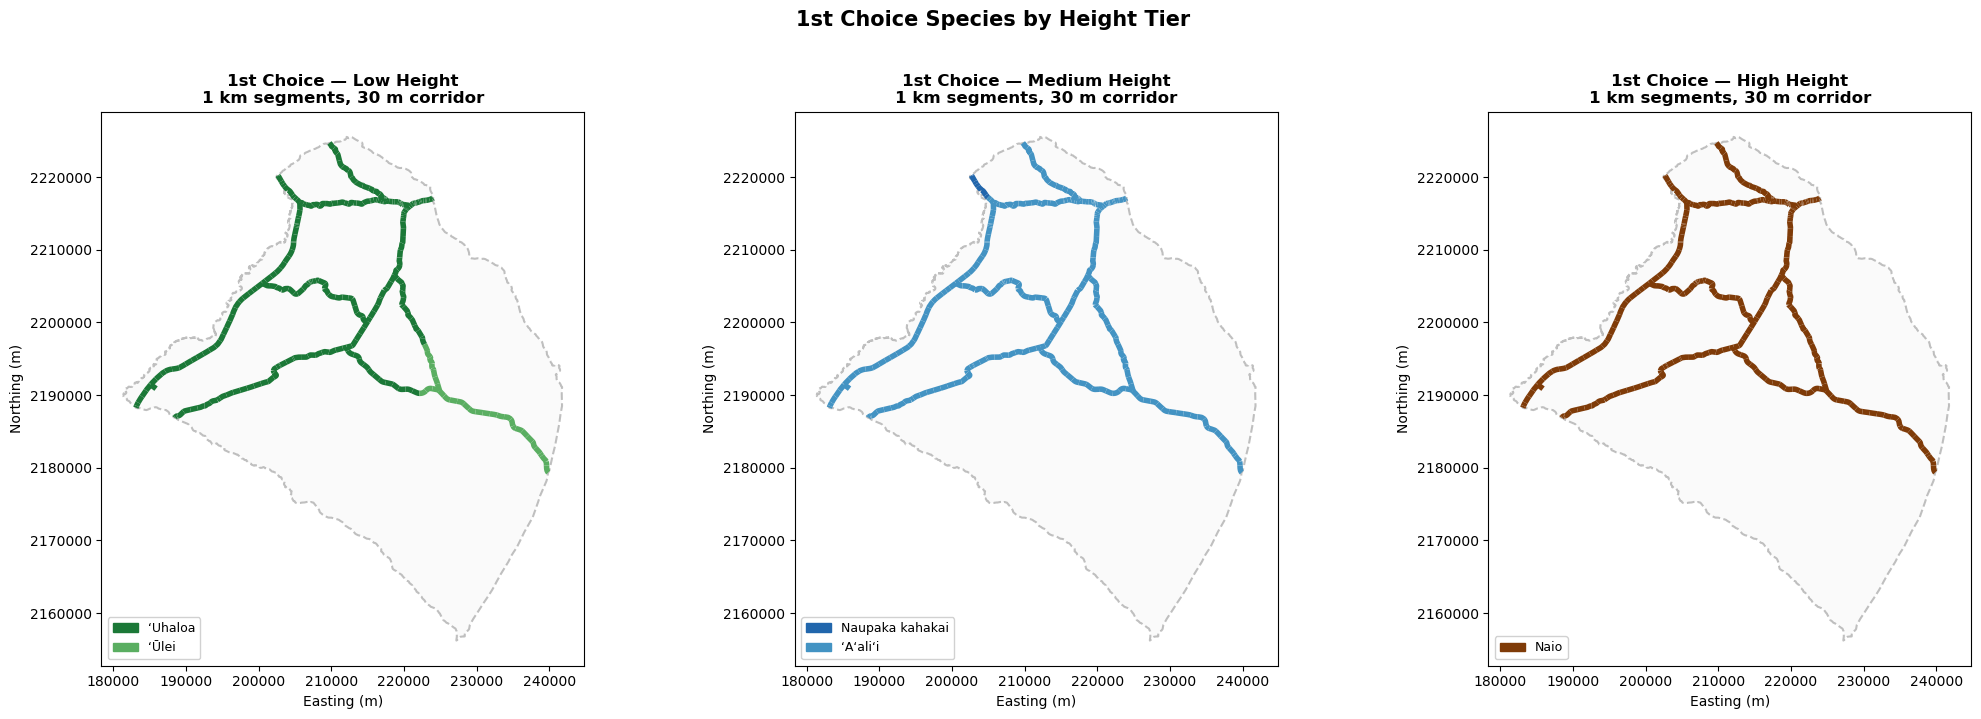

In [25]:
# Cell 6 - 1st Choice Species Map (Low / Medium / High)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
tier_names = {"L": "Low Height", "M": "Medium Height", "H": "High Height"}

for ax, tier in zip(axes, HEIGHT_TIERS):
    boundary_utm.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#333",
                      linewidth=1.5, linestyle="--", alpha=0.3)

    col = f"choice_1_{tier}_species"
    no_sp_mask = segments[col].isna()

    if no_sp_mask.any():
        segments[no_sp_mask].plot(ax=ax, color=NO_SPECIES_COLOR, linewidth=2, alpha=0.4)

    legend_handles = []
    for species_name in SPECIES_FILES.keys():
        sp_tier = tier_lookup.get(norm(species_name), "?")
        if sp_tier != tier:
            continue
        color = SPECIES_COLORS.get(species_name, "#888")
        mask  = segments[col] == species_name
        if mask.any():
            segments[mask].plot(ax=ax, color=color, linewidth=4)
            legend_handles.append(mpatches.Patch(color=color, label=species_name))

    if no_sp_mask.any():
        legend_handles.append(mpatches.Patch(color=NO_SPECIES_COLOR, label="No species"))

    ax.set_title(f"1st Choice — {tier_names[tier]}\n1 km segments, 30 m corridor",
                 fontsize=12, fontweight="bold")
    ax.legend(handles=legend_handles, loc="lower left", fontsize=9, framealpha=0.9)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="plain")
    ax.set_aspect("equal")

plt.suptitle(f"1st Choice Species by Height Tier", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(f"choice_1_species_LMH.jpg", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()


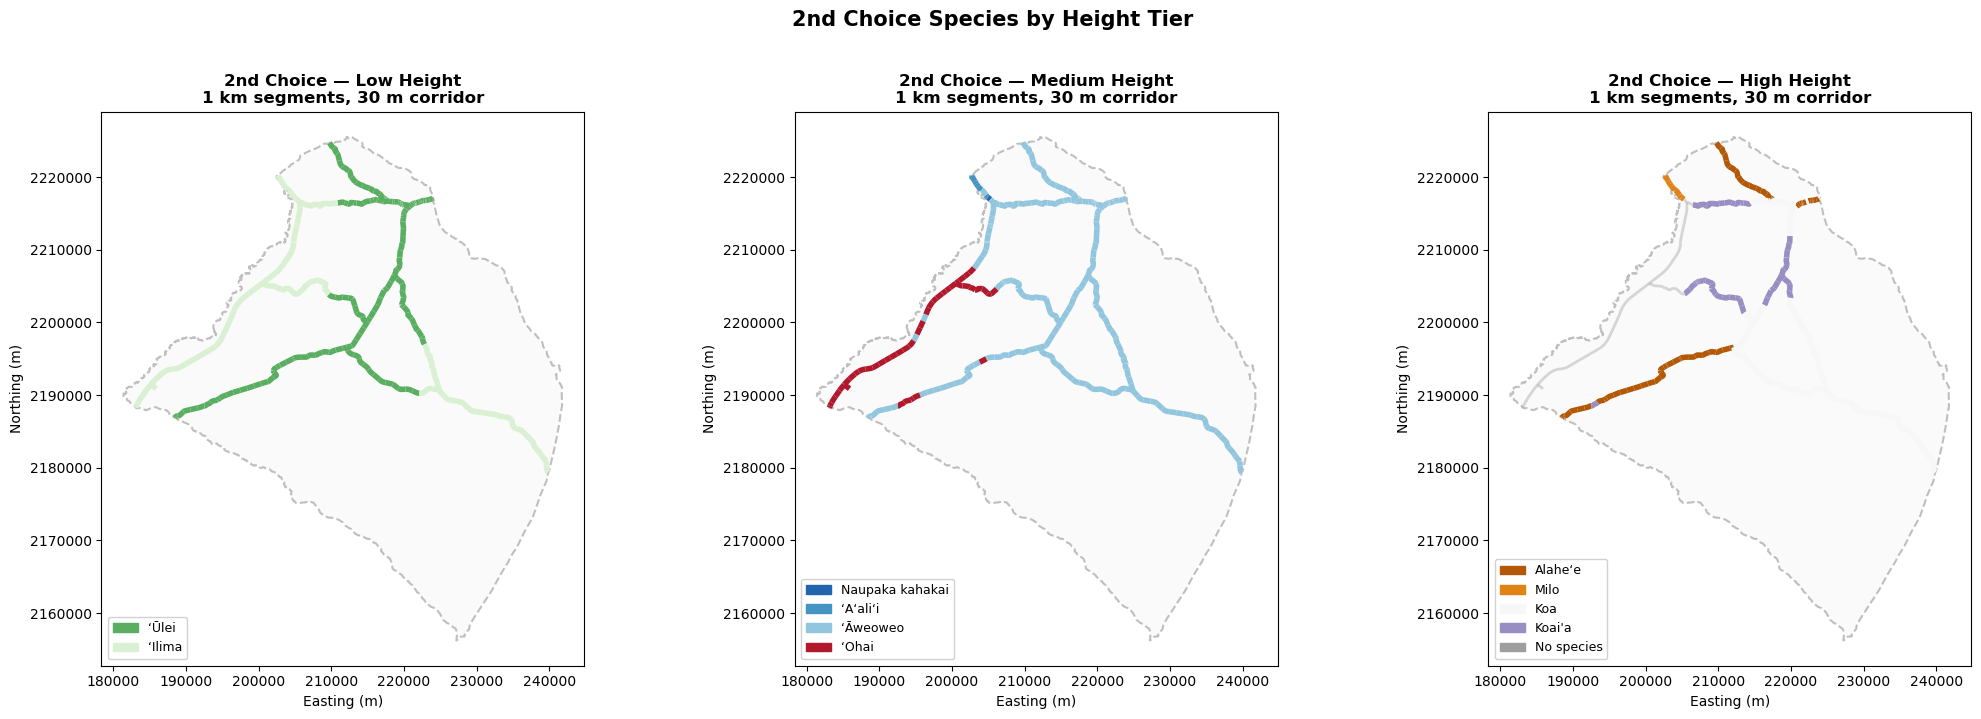

In [26]:
# Cell 7 - 2nd Choice Species Map (Low / Medium / High)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
tier_names = {"L": "Low Height", "M": "Medium Height", "H": "High Height"}

for ax, tier in zip(axes, HEIGHT_TIERS):
    boundary_utm.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#333",
                      linewidth=1.5, linestyle="--", alpha=0.3)

    col = f"choice_2_{tier}_species"
    no_sp_mask = segments[col].isna()

    if no_sp_mask.any():
        segments[no_sp_mask].plot(ax=ax, color=NO_SPECIES_COLOR, linewidth=2, alpha=0.4)

    legend_handles = []
    for species_name in SPECIES_FILES.keys():
        sp_tier = tier_lookup.get(norm(species_name), "?")
        if sp_tier != tier:
            continue
        color = SPECIES_COLORS.get(species_name, "#888")
        mask  = segments[col] == species_name
        if mask.any():
            segments[mask].plot(ax=ax, color=color, linewidth=4)
            legend_handles.append(mpatches.Patch(color=color, label=species_name))

    if no_sp_mask.any():
        legend_handles.append(mpatches.Patch(color=NO_SPECIES_COLOR, label="No species"))

    ax.set_title(f"2nd Choice — {tier_names[tier]}\n1 km segments, 30 m corridor",
                 fontsize=12, fontweight="bold")
    ax.legend(handles=legend_handles, loc="lower left", fontsize=9, framealpha=0.9)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="plain")
    ax.set_aspect("equal")

plt.suptitle(f"2nd Choice Species by Height Tier", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(f"choice_2_species_LMH.jpg", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()


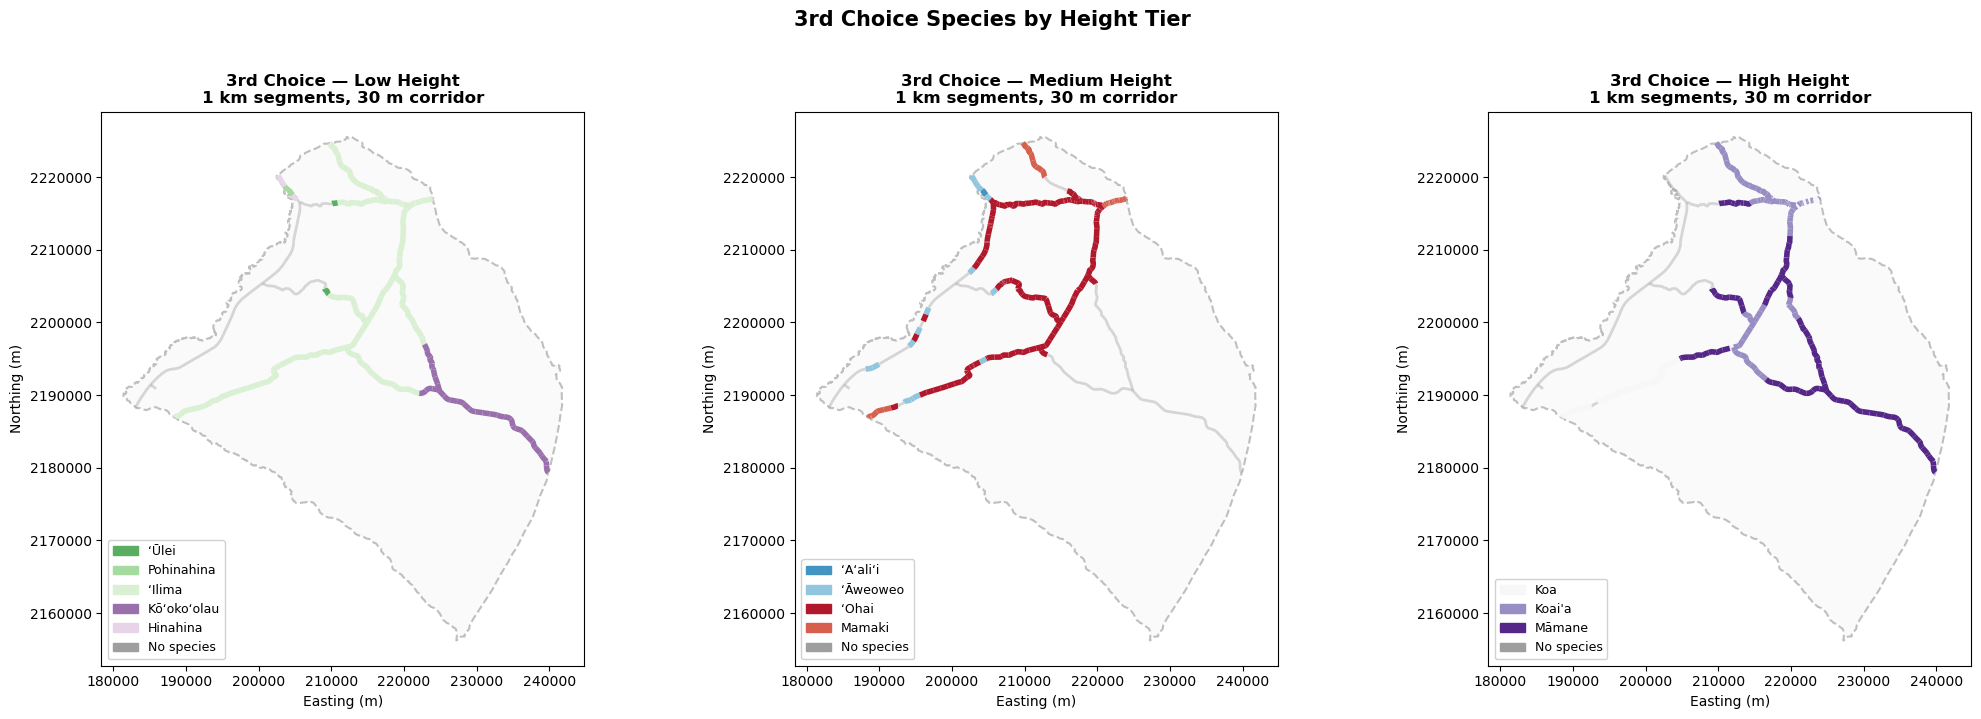

In [27]:
# Cell 8 - 3rd Choice Species Map (Low / Medium / High)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
tier_names = {"L": "Low Height", "M": "Medium Height", "H": "High Height"}

for ax, tier in zip(axes, HEIGHT_TIERS):
    boundary_utm.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#333",
                      linewidth=1.5, linestyle="--", alpha=0.3)

    col = f"choice_3_{tier}_species"
    no_sp_mask = segments[col].isna()

    if no_sp_mask.any():
        segments[no_sp_mask].plot(ax=ax, color=NO_SPECIES_COLOR, linewidth=2, alpha=0.4)

    legend_handles = []
    for species_name in SPECIES_FILES.keys():
        sp_tier = tier_lookup.get(norm(species_name), "?")
        if sp_tier != tier:
            continue
        color = SPECIES_COLORS.get(species_name, "#888")
        mask  = segments[col] == species_name
        if mask.any():
            segments[mask].plot(ax=ax, color=color, linewidth=4)
            legend_handles.append(mpatches.Patch(color=color, label=species_name))

    if no_sp_mask.any():
        legend_handles.append(mpatches.Patch(color=NO_SPECIES_COLOR, label="No species"))

    ax.set_title(f"3rd Choice — {tier_names[tier]}\n1 km segments, 30 m corridor",
                 fontsize=12, fontweight="bold")
    ax.legend(handles=legend_handles, loc="lower left", fontsize=9, framealpha=0.9)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="plain")
    ax.set_aspect("equal")

plt.suptitle(f"3rd Choice Species by Height Tier", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(f"choice_3_species_LMH.jpg", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()


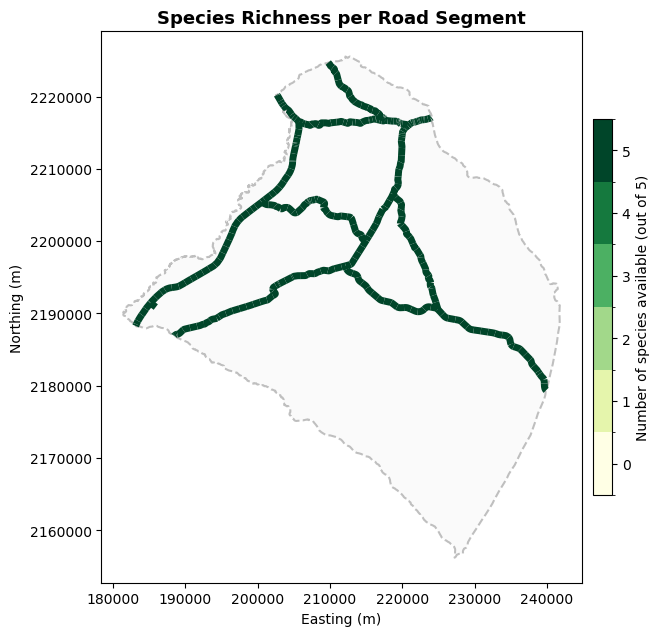

  5 species: 33 segments


In [28]:
# Cell 9 - Species Richness Map

from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

# Count how many of the top 5 species are available per segment
segments["n_species"] = segments["seg_id"].apply(
    lambda sid: len(results.get(sid, {})))

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
boundary_utm.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#333", linewidth=1.5, linestyle="--", alpha=0.3)

cmap = plt.cm.YlGn  # light yellow (0) to dark green (5)
bounds_vals = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
bnorm = BoundaryNorm(bounds_vals, cmap.N)

for _, row in segments.iterrows():
    n = row["n_species"]
    color = cmap(bnorm(n))
    geom = row.geometry
    parts = list(geom.geoms) if geom.geom_type == "MultiLineString" else [geom]
    for part in parts:
        xs, ys = part.xy
        ax.plot(xs, ys, color=color, linewidth=5, solid_capstyle="butt")

sm = ScalarMappable(cmap=cmap, norm=bnorm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=[0, 1, 2, 3, 4, 5], shrink=0.6, pad=0.02)
cbar.set_label("Number of species available (out of 5)", fontsize=10)

ax.set_title("Species Richness per Road Segment",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain")
ax.set_aspect("equal")
plt.tight_layout()
fig.savefig("species_richness.jpg", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# Summary
for n in range(6):
    cnt = (segments["n_species"] == n).sum()
    if cnt > 0:
        print(f"  {n} species: {cnt} segments")

IndexError: index 6 is out of bounds for axis 0 with size 6

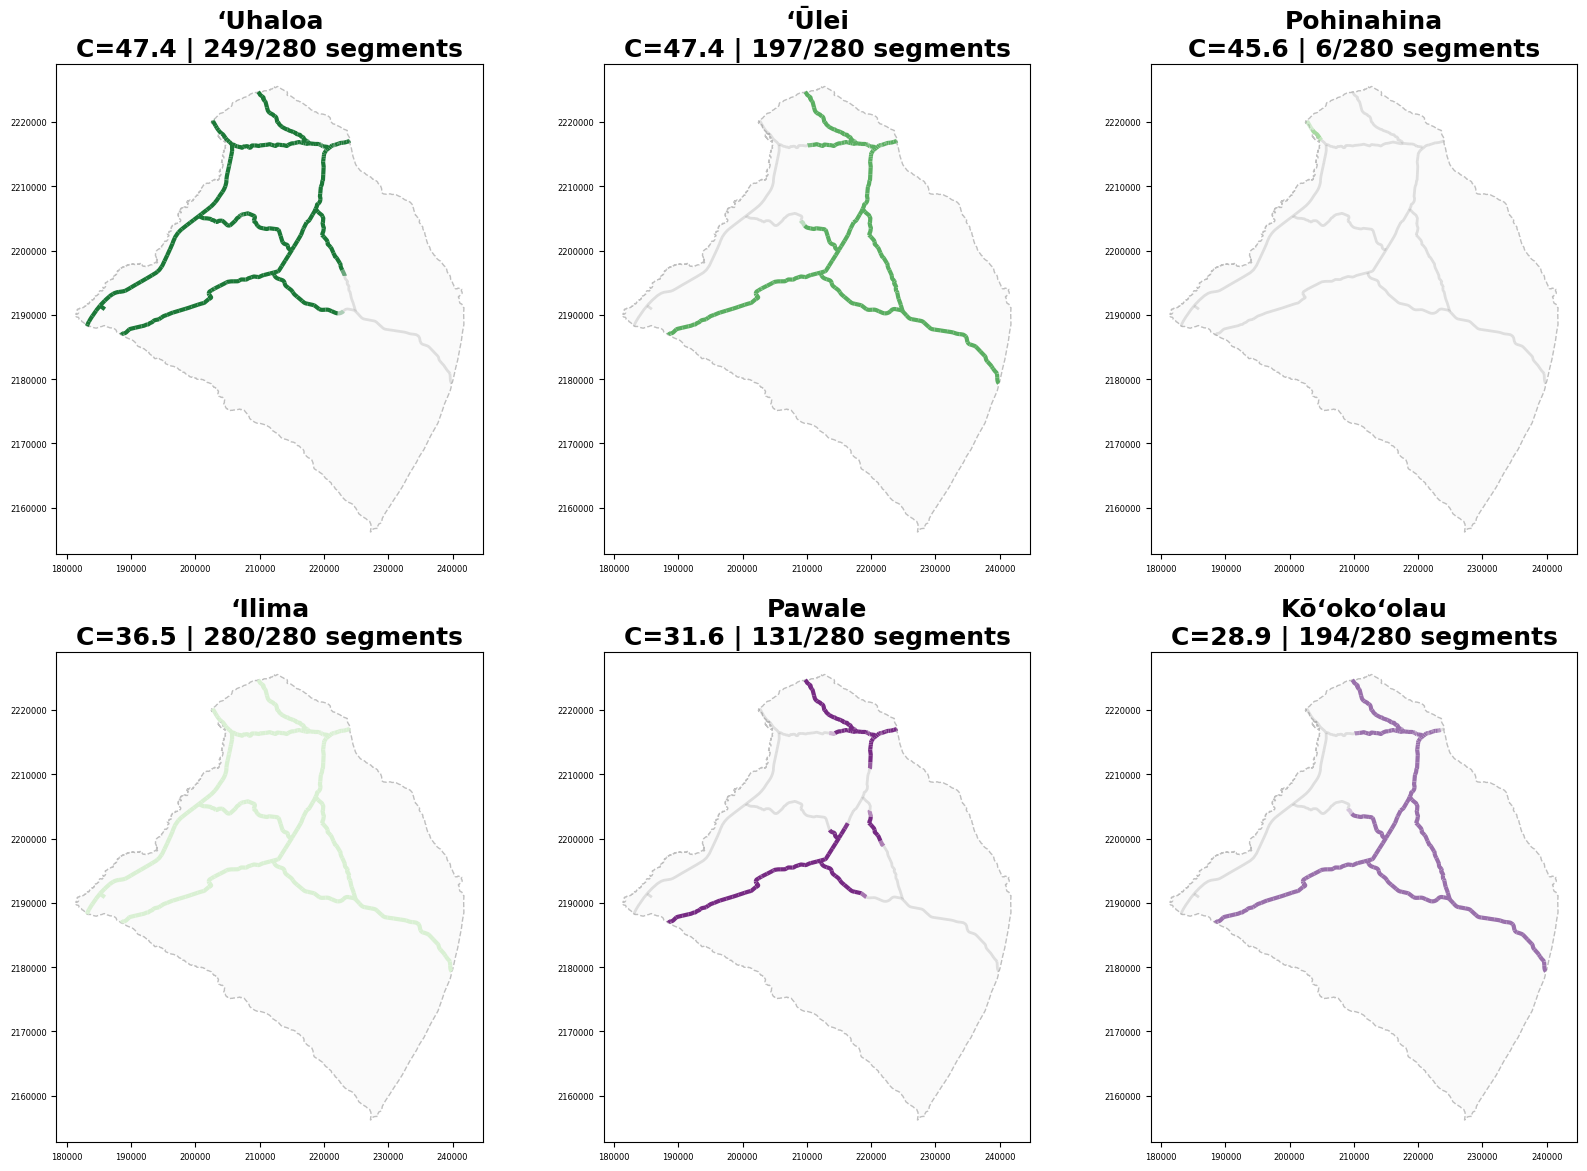

In [29]:
# Cell 10 - Individual Species Coverage Maps

from matplotlib.colors import Normalize

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for idx, (species_name, shp_base) in enumerate(SPECIES_FILES.items()):
    ax = axes[idx]
    boundary_utm.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#333", linewidth=1, linestyle="--", alpha=0.3)

    # Get coverage for this species per segment
    coverages = []
    for _, row in segments.iterrows():
        sid = row["seg_id"]
        sp_info = results.get(sid, {}).get(species_name)
        coverages.append(sp_info["coverage"] if sp_info else 0)
    segments["_cov"] = coverages

    # Plot segments with no coverage
    no_cov = segments[segments["_cov"] == 0]
    if len(no_cov) > 0:
        no_cov.plot(ax=ax, color=NO_SPECIES_COLOR, linewidth=2, alpha=0.3)

    # Plot segments with coverage, colored by coverage fraction
    has_cov = segments[segments["_cov"] > 0]
    if len(has_cov) > 0:
        color = SPECIES_COLORS[species_name]
        for _, row in has_cov.iterrows():
            cov = row["_cov"]
            alpha = 0.3 + 0.7 * cov  # scale alpha by coverage
            geom = row.geometry
            parts = list(geom.geoms) if geom.geom_type == "MultiLineString" else [geom]
            for part in parts:
                xs, ys = part.xy
                ax.plot(xs, ys, color=color, linewidth=3, alpha=alpha, solid_capstyle="butt")

    C = score_lookup.get(species_name, 0)
    n_present = (segments["_cov"] > 0).sum()
    ax.set_title(f"{species_name}\nC={C:.1f} | {n_present}/{len(segments)} segments",
                 fontsize=18, fontweight="bold")
    ax.set_aspect("equal")
    ax.ticklabel_format(style="plain")
    ax.tick_params(labelsize=6)

# Hide unused subplot (6th)
axes[5].set_visible(False)

segments.drop(columns=["_cov"], inplace=True)

plt.suptitle("Individual Species Coverage Maps\n(Darker = higher corridor coverage)",
             fontsize=20, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig("species_cover_maps.jpg", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
# Cell 11 - Output locations
import glob

shp_files = glob.glob("road_segments_scored.*")
print(f"road_segments_scored: {shp_files}")
print(f"\nFiles saved in: {os.getcwd()}")
